In [2]:
import pandas as pd

In [3]:
import pandas as pd

df = pd.read_csv("data/train.csv",nrows=200000)

df.head()
df.info()
df.describe()
df.isnull().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    200000 non-null  object
 1   store   200000 non-null  int64 
 2   item    200000 non-null  int64 
 3   sales   200000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 6.1+ MB


date     0
store    0
item     0
sales    0
dtype: int64

In [4]:
df['date']=pd.to_datetime(df['date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    200000 non-null  datetime64[ns]
 1   store   200000 non-null  int64         
 2   item    200000 non-null  int64         
 3   sales   200000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 6.1 MB


In [6]:
df['date'].min(), df['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [7]:
df['store'].nunique()


10

In [8]:
df['item'].nunique()

11

In [9]:
df['date'].nunique()


1826

In [10]:
df = df.sort_values(by=['store', 'item', 'date'])

In [11]:
df.duplicated().sum()

0

In [12]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

In [13]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter
0,2013-01-01,1,1,13,2013,1,1,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2,1,1
2,2013-01-03,1,1,14,2013,1,3,3,1,1
3,2013-01-04,1,1,13,2013,1,4,4,1,1
4,2013-01-05,1,1,10,2013,1,5,5,1,1


In [14]:
#create weekend feature
df["is_weekend"]=df["day_of_week"].isin([5,6]).astype(int)

#1 = weekend

#0 = weekday


In [15]:
df.head(10)

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1
5,2013-01-06,1,1,12,2013,1,6,6,1,1,1
6,2013-01-07,1,1,10,2013,1,7,0,2,1,0
7,2013-01-08,1,1,9,2013,1,8,1,2,1,0
8,2013-01-09,1,1,12,2013,1,9,2,2,1,0
9,2013-01-10,1,1,9,2013,1,10,3,2,1,0


In [16]:
df.columns

Index(['date', 'store', 'item', 'sales', 'year', 'month', 'day', 'day_of_week',
       'week_of_year', 'quarter', 'is_weekend'],
      dtype='object')

In [17]:
df['lag_1'] = df.groupby(['store', 'item'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)

In [18]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0,13.0,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0,11.0,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0,14.0,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1,13.0,NaN,NaN


In [19]:
df.isnull().sum()

date               0
store              0
item               0
sales              0
year               0
month              0
day                0
day_of_week        0
week_of_year       0
quarter            0
is_weekend         0
lag_1            110
lag_7            770
lag_30          3300
dtype: int64

In [20]:
df = df.dropna()

In [21]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30
30,2013-01-31,1,1,13,2013,1,31,3,5,1,0,9.0,8.0,13.0
31,2013-02-01,1,1,11,2013,2,1,4,5,1,0,13.0,14.0,11.0
32,2013-02-02,1,1,21,2013,2,2,5,5,1,1,11.0,12.0,14.0
33,2013-02-03,1,1,15,2013,2,3,6,5,1,1,21.0,12.0,13.0
34,2013-02-04,1,1,14,2013,2,4,0,6,1,0,15.0,11.0,10.0


In [22]:
df['rolling_mean_7'] = (
    df.groupby(['store', 'item'])['sales']
      .shift(1)
      .rolling(window=7)
      .mean()
)

df['rolling_mean_30'] = (
    df.groupby(['store', 'item'])['sales']
      .shift(1)
      .rolling(window=30)
      .mean()
)

In [23]:
df.isnull().sum()

date                  0
store                 0
item                  0
sales                 0
year                  0
month                 0
day                   0
day_of_week           0
week_of_year          0
quarter               0
is_weekend            0
lag_1                 0
lag_7                 0
lag_30                0
rolling_mean_7      770
rolling_mean_30    3300
dtype: int64

In [24]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
30,2013-01-31,1,1,13,2013,1,31,3,5,1,0,9.0,8.0,13.0,NaN,NaN
31,2013-02-01,1,1,11,2013,2,1,4,5,1,0,13.0,14.0,11.0,NaN,NaN
32,2013-02-02,1,1,21,2013,2,2,5,5,1,1,11.0,12.0,14.0,NaN,NaN
33,2013-02-03,1,1,15,2013,2,3,6,5,1,1,21.0,12.0,13.0,NaN,NaN
34,2013-02-04,1,1,14,2013,2,4,0,6,1,0,15.0,11.0,10.0,NaN,NaN


In [25]:
df = df.dropna()

In [26]:
df.shape

(193400, 16)

In [27]:
df.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
60,2013-03-02,1,1,13,2013,3,2,5,9,1,1,15.0,15.0,13.0,10.857143,11.666667
61,2013-03-03,1,1,20,2013,3,3,6,9,1,1,13.0,11.0,11.0,10.571429,11.666667
62,2013-03-04,1,1,14,2013,3,4,0,10,1,0,20.0,7.0,21.0,11.857143,11.966667
63,2013-03-05,1,1,13,2013,3,5,1,10,1,0,14.0,9.0,15.0,12.857143,11.733333
64,2013-03-06,1,1,17,2013,3,6,2,10,1,0,13.0,9.0,14.0,13.428571,11.666667


In [28]:
df['date'].min(), df['date'].max()

(Timestamp('2013-03-02 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [29]:
train = df[df['date'] < '2017-01-01']
val = df[df['date'] >= '2017-01-01']

In [30]:
train.shape



(153615, 16)

In [31]:
val.shape

(39785, 16)

In [32]:
val['date'].min(), val['date'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [33]:
y_train = train['sales']
y_val = val['sales']

In [34]:
#We must drop:

#date → model doesn’t need raw date now

#sales → because that’s the target


X_train = train.drop(columns=['date', 'sales'])
X_val = val.drop(columns=['date', 'sales'])

In [35]:
X_train.shape

(153615, 14)

In [36]:
X_val.shape


(39785, 14)

In [37]:
X_train.dtypes

store                int64
item                 int64
year                 int64
month                int64
day                  int64
day_of_week          int64
week_of_year         int32
quarter              int64
is_weekend           int32
lag_1              float64
lag_7              float64
lag_30             float64
rolling_mean_7     float64
rolling_mean_30    float64
dtype: object

In [38]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=80, n_jobs=-1, random_state=42)

In [39]:
X_train.shape

(153615, 14)

In [40]:
y_train.shape

(153615,)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.246638277309497
RMSE: 8.210618328266886


In [42]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))

rolling_mean_7     0.764407
lag_7              0.174727
day_of_week        0.021838
lag_1              0.018123
rolling_mean_30    0.013357
month              0.002017
week_of_year       0.001918
day                0.001260
is_weekend         0.001223
lag_30             0.000734
store              0.000145
item               0.000130
year               0.000090
quarter            0.000032
dtype: float64


In [43]:
import joblib
joblib.dump(model, "model/sales_forecast_model.pkl", compress=3)

['model/sales_forecast_model.pkl']

In [44]:
import joblib

model = joblib.load("model/sales_forecast_model.pkl")

In [45]:
print(X_train.columns)
print(X_val.columns)

Index(['store', 'item', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7',
       'rolling_mean_30'],
      dtype='object')
Index(['store', 'item', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7',
       'rolling_mean_30'],
      dtype='object')


In [46]:
train['weekend'] = train['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
val['weekend'] = val['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

train['is_weekend'] = train['weekend']
val['is_weekend'] = val['weekend']

C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\1024445515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['weekend'] = train['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\1024445515.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['weekend'] = val['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\1024445515.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [47]:
X_train = train.drop(['sales','date'], axis=1)
y_train = train['sales']

X_val = val.drop(['sales','date'], axis=1)
y_val = val['sales']

In [48]:
print(X_train.columns)

Index(['store', 'item', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
       'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7',
       'rolling_mean_30', 'weekend'],
      dtype='object')


In [52]:
correct_order = [
    'store',
    'item',
    'year',
    'month',
    'day',
    'day_of_week',
    'week_of_year',
    'quarter',
    
    'is_weekend',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30'
]

X_train = X_train[correct_order]
X_val = X_val[correct_order]

In [53]:
y_pred = model.predict(X_val)

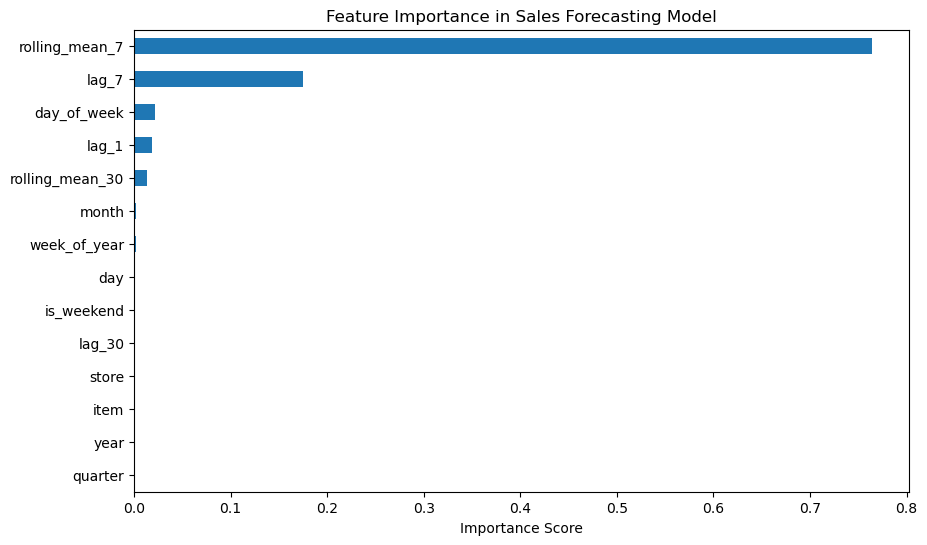

In [54]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(kind='barh', figsize=(10,6))

plt.title("Feature Importance in Sales Forecasting Model")
plt.xlabel("Importance Score")

plt.show()

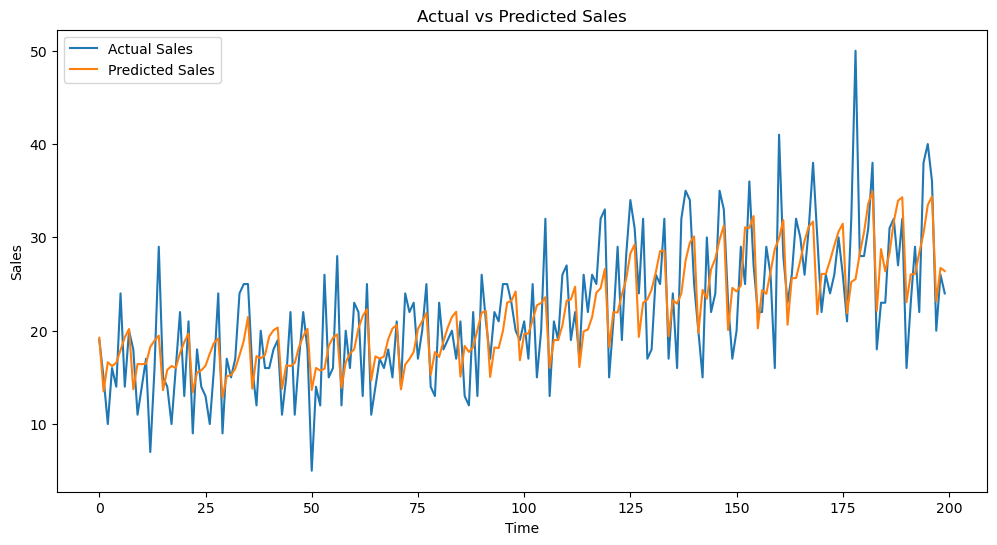

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_val.values[:200], label="Actual Sales")
plt.plot(y_pred[:200], label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.show()

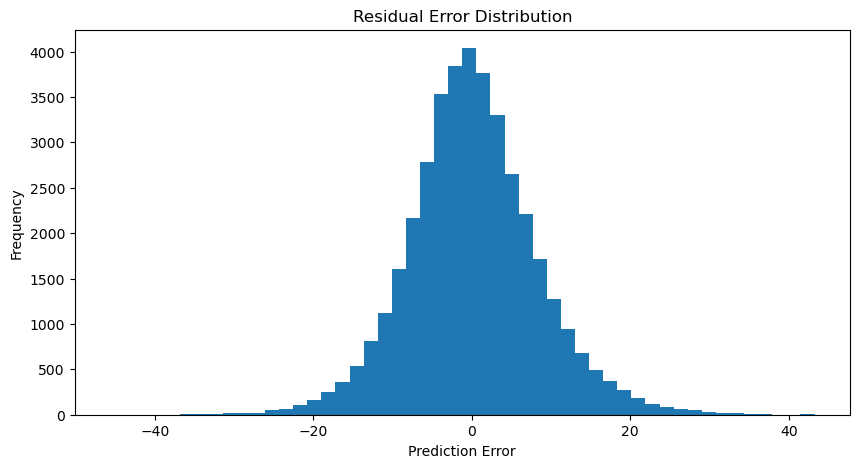

In [56]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=50)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [57]:
latest_data = df.groupby(['store','item']).tail(1)

print(latest_data.shape)
latest_data.head()

(110, 16)


,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
1825,2017-12-31,1,1,23,2017,12,31,6,52,4,1,27.0,19.0,19.0,17.571429,17.000000
20085,2017-12-31,1,2,67,2017,12,31,6,52,4,1,56.0,47.0,56.0,48.285714,46.933333
38345,2017-12-31,1,3,29,2017,12,31,6,52,4,1,27.0,33.0,30.0,27.000000,28.133333
56605,2017-12-31,1,4,15,2017,12,31,6,52,4,1,19.0,11.0,23.0,16.714286,16.066667
74865,2017-12-31,1,5,17,2017,12,31,6,52,4,1,22.0,15.0,13.0,13.857143,13.966667


In [58]:
X_future = latest_data.drop(['sales','date'], axis=1)

X_future = X_future[correct_order]

In [59]:
latest_data['weekend'] = latest_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
latest_data['is_weekend'] = latest_data['weekend']

C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\2231062086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_data['weekend'] = latest_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\2231062086.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_data['is_weekend'] = latest_data['weekend']


In [60]:
future_predictions = model.predict(X_future)

latest_data['predicted_sales_next_day'] = future_predictions

latest_data[['store','item','predicted_sales_next_day']].head(10)

C:\Users\arinr\AppData\Local\Temp\ipykernel_12816\2163351351.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_data['predicted_sales_next_day'] = future_predictions


,store,item,predicted_sales_next_day
1825,1,1,19.048991
20085,1,2,54.996514
38345,1,3,30.982485
56605,1,4,18.164609
74865,1,5,15.950110
93125,1,6,51.685551
111385,1,7,51.138803
129645,1,8,68.003580
147905,1,9,42.361808
166165,1,10,66.054086


In [61]:
latest_data[['store','item','predicted_sales_next_day']].to_csv("future_sales_predictions.csv", index=False)

In [62]:
plt.savefig("feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [63]:
latest_data.head()

,date,store,item,sales,year,month,day,day_of_week,week_of_year,quarter,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,weekend,predicted_sales_next_day
1825,2017-12-31,1,1,23,2017,12,31,6,52,4,1,27.0,19.0,19.0,17.571429,17.000000,1,19.048991
20085,2017-12-31,1,2,67,2017,12,31,6,52,4,1,56.0,47.0,56.0,48.285714,46.933333,1,54.996514
38345,2017-12-31,1,3,29,2017,12,31,6,52,4,1,27.0,33.0,30.0,27.000000,28.133333,1,30.982485
56605,2017-12-31,1,4,15,2017,12,31,6,52,4,1,19.0,11.0,23.0,16.714286,16.066667,1,18.164609
74865,2017-12-31,1,5,17,2017,12,31,6,52,4,1,22.0,15.0,13.0,13.857143,13.966667,1,15.950110


In [2]:
import joblib

model = joblib.load("model/sales_forecast_model.pkl")
print(model.feature_names_in_)

['store' 'item' 'year' 'month' 'day' 'day_of_week' 'week_of_year'
 'quarter' 'is_weekend' 'lag_1' 'lag_7' 'lag_30' 'rolling_mean_7'
 'rolling_mean_30']


In [3]:
import joblib
joblib.dump(model, "sales_forecast_model.pkl")

['sales_forecast_model.pkl']